In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("MOCK_DATA (3).csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (250, 7)


,Student Name,Email,Phone,Program Applied,College,Application Date,Admission Status
0,Gabbie Andrew,gandrew0@booking.com,690-764-8136,artificial intelligence,University of Mary,9/27/2025,PENDING
1,NaN,gwellfare1@bing.com,NaN,SOFTWARE ENGINEERING,Universidad Braulio Carrillo,11/27/2025,Pending
2,Trenna Bartolozzi,tbartolozzi2@a8.net,164-612-4384,Artificial Intelligence,Bunka Women's University,11/21/2025,accepted
3,Cristie O'Lunney,colunney3@jalbum.net,499-637-5837,Artificial Intelligence,Ecole de l'Air,5/28/2026,Pending
4,NaN,pmendus4@boston.com,764-393-2004,Cyber Security,"Long Island University, Southampton College",10/19/2025,ACCEPTED


In [3]:
np.random.seed(42)

df["num_skills_listed"] = np.random.randint(1, 9, size=len(df))

df["has_portfolio"] = np.random.choice(
    ["Yes", "No"],
    size=len(df),
    p=[0.4, 0.6]
)

df["prior_hackathon_participation"] = np.random.choice(
    ["Yes", "No"],
    size=len(df),
    p=[0.3, 0.7]
)

df["statement_quality_score"] = np.random.randint(
    1, 11,
    size=len(df)
)

df.head()

,Student Name,Email,Phone,Program Applied,College,Application Date,Admission Status,num_skills_listed,has_portfolio,prior_hackathon_participation,statement_quality_score
0,Gabbie Andrew,gandrew0@booking.com,690-764-8136,artificial intelligence,University of Mary,9/27/2025,PENDING,7,No,No,7
1,NaN,gwellfare1@bing.com,NaN,SOFTWARE ENGINEERING,Universidad Braulio Carrillo,11/27/2025,Pending,4,No,No,8
2,Trenna Bartolozzi,tbartolozzi2@a8.net,164-612-4384,Artificial Intelligence,Bunka Women's University,11/21/2025,accepted,5,No,Yes,2
3,Cristie O'Lunney,colunney3@jalbum.net,499-637-5837,Artificial Intelligence,Ecole de l'Air,5/28/2026,Pending,7,Yes,No,10
4,NaN,pmendus4@boston.com,764-393-2004,Cyber Security,"Long Island University, Southampton College",10/19/2025,ACCEPTED,3,No,Yes,8


In [4]:
print(df.shape)
print(df.columns.tolist())

(250, 11)
['Student Name', 'Email', 'Phone', 'Program Applied', 'College', 'Application Date', 'Admission Status', 'num_skills_listed', 'has_portfolio', 'prior_hackathon_participation', 'statement_quality_score']


In [5]:
df[
    [
        "num_skills_listed",
        "has_portfolio",
        "prior_hackathon_participation",
        "statement_quality_score"
    ]
].head(10)

,num_skills_listed,has_portfolio,prior_hackathon_participation,statement_quality_score
0,7,No,No,7
1,4,No,No,8
2,5,No,Yes,2
3,7,Yes,No,10
4,3,No,Yes,8
5,8,No,Yes,3
6,5,Yes,No,7
7,5,Yes,No,3
8,7,Yes,No,7
9,2,No,No,2


In [6]:
# Normalize Admission Status
df["Admission Status"] = (
    df["Admission Status"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Check all status values
print(df["Admission Status"].value_counts(dropna=False))

Admission Status
rejected    85
accepted    75
pending     65
nan         25
Name: count, dtype: int64


In [7]:
# Keep only applicants with confirmed outcomes
df_model = df[
    df["Admission Status"].isin(["accepted", "rejected"])
].copy()

# Create target
df_model["target"] = (
    df_model["Admission Status"] == "accepted"
).astype(int)

print("Original rows:", len(df))
print("Rows used for model:", len(df_model))

print("\nTarget distribution:")
print(df_model["target"].value_counts())

Original rows: 250
Rows used for model: 160

Target distribution:
target
0    85
1    75
Name: count, dtype: int64


In [8]:
df_model["has_portfolio"] = df_model["has_portfolio"].map({
    "Yes": 1,
    "No": 0
})

df_model["prior_hackathon_participation"] = df_model[
    "prior_hackathon_participation"
].map({
    "Yes": 1,
    "No": 0
})

df_model[[
    "has_portfolio",
    "prior_hackathon_participation"
]].head()

,has_portfolio,prior_hackathon_participation
2,0,1
4,0,1
6,1,0
7,1,0
8,1,0


In [9]:
df_model = pd.get_dummies(
    df_model,
    columns=["Program Applied"],
    drop_first=True
)

df_model.head()

,Student Name,Email,Phone,College,Application Date,Admission Status,num_skills_listed,has_portfolio,prior_hackathon_participation,statement_quality_score,...,Program Applied_Cyber Security,Program Applied_DATA SCIENCE,Program Applied_Data Science,Program Applied_SOFTWARE ENGINEERING,Program Applied_Software Engineering,Program Applied_artificial intelligence,Program Applied_computer science,Program Applied_cyber security,Program Applied_data science,Program Applied_software engineering
2,Trenna Bartolozzi,tbartolozzi2@a8.net,164-612-4384,Bunka Women's University,11/21/2025,accepted,5,0,1,2,...,False,False,False,False,False,False,False,False,False,False
4,NaN,pmendus4@boston.com,764-393-2004,"Long Island University, Southampton College",10/19/2025,accepted,3,0,1,8,...,True,False,False,False,False,False,False,False,False,False
6,Gerik Steynor,gsteynor6@paginegialle.it,220-762-8074,NaN,2/19/2026,rejected,5,1,0,7,...,False,False,False,False,False,False,False,False,False,False
7,Michaeline Waugh,mwaugh7@usa.gov,339-455-8596,NaN,8/20/2025,rejected,5,1,0,3,...,False,False,False,False,False,True,False,False,False,False
8,Sanson Charlson,scharlson8@reference.com,453-962-8079,Universidad de Antofagasta,4/5/2026,accepted,7,1,0,7,...,False,False,False,False,False,False,False,False,False,False


In [10]:
feature_columns = [
    "num_skills_listed",
    "has_portfolio",
    "prior_hackathon_participation",
    "statement_quality_score"
]

feature_columns += [
    col for col in df_model.columns
    if col.startswith("Program Applied_")
]

X = df_model[feature_columns]
y = df_model["target"]

print("Features:")
print(X.columns.tolist())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['num_skills_listed', 'has_portfolio', 'prior_hackathon_participation', 'statement_quality_score', 'Program Applied_Artificial Intelligence', 'Program Applied_COMPUTER SCIENCE', 'Program Applied_CYBER SECURITY', 'Program Applied_Computer Science', 'Program Applied_Cyber Security', 'Program Applied_DATA SCIENCE', 'Program Applied_Data Science', 'Program Applied_SOFTWARE ENGINEERING', 'Program Applied_Software Engineering', 'Program Applied_artificial intelligence', 'Program Applied_computer science', 'Program Applied_cyber security', 'Program Applied_data science', 'Program Applied_software engineering']

X shape: (160, 18)
y shape: (160,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 128
Testing samples: 32


In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [13]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 1 1 1 0 1 1 1 1]


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)

print(f"Accuracy: {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")

Accuracy: 50.00%
Precision: 58.33%
Recall: 38.89%


Confusion Matrix:
[[ 9  5]
 [11  7]]


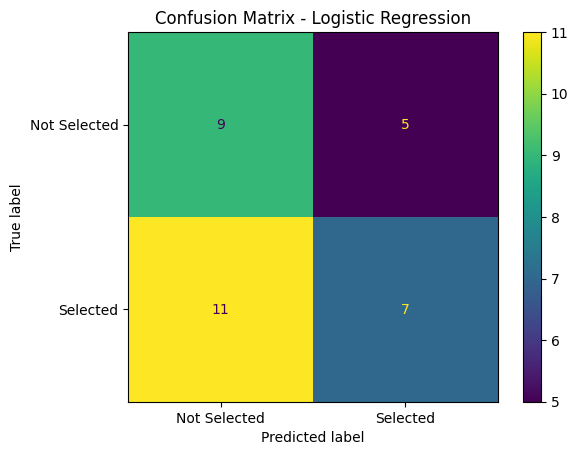

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Selected", "Selected"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
### Model Evaluation

The Logistic Regression model was evaluated using accuracy, precision recall, and a confusion matrix.

- **Accuracy** shows the overall percentage of correct predictions.
- **Precision** shows how many applicants predicted as selected were actually selected.
- **Recall** shows how many of the actually selected applicants were correctly identified.
- The **confusion matrix** shows correct and incorrect predictions for both classes.

Because this dataset is small and contains simulated features, these results should be treated as an exercise rather than evidence that the model would perform the same way on real applicants.

In [17]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
17,Program Applied_software engineering,1.069241
14,Program Applied_computer science,0.344534
2,prior_hackathon_participation,0.295165
8,Program Applied_Cyber Security,0.136592
4,Program Applied_Artificial Intelligence,0.068249
7,Program Applied_Computer Science,0.060086
3,statement_quality_score,-0.073536
0,num_skills_listed,-0.131664
9,Program Applied_DATA SCIENCE,-0.157308
12,Program Applied_Software Engineering,-0.215618


In [18]:
print("Top Positive Predictors:")
display(coefficients.head(10))

print("\nTop Negative Predictors:")
display(coefficients.tail(10))

Top Positive Predictors:


,Feature,Coefficient
17,Program Applied_software engineering,1.069241
14,Program Applied_computer science,0.344534
2,prior_hackathon_participation,0.295165
8,Program Applied_Cyber Security,0.136592
4,Program Applied_Artificial Intelligence,0.068249
7,Program Applied_Computer Science,0.060086
3,statement_quality_score,-0.073536
0,num_skills_listed,-0.131664
9,Program Applied_DATA SCIENCE,-0.157308
12,Program Applied_Software Engineering,-0.215618



Top Negative Predictors:


,Feature,Coefficient
9,Program Applied_DATA SCIENCE,-0.157308
12,Program Applied_Software Engineering,-0.215618
10,Program Applied_Data Science,-0.399741
6,Program Applied_CYBER SECURITY,-0.465909
1,has_portfolio,-0.466407
11,Program Applied_SOFTWARE ENGINEERING,-0.480689
15,Program Applied_cyber security,-0.489971
5,Program Applied_COMPUTER SCIENCE,-0.537478
13,Program Applied_artificial intelligence,-0.645978
16,Program Applied_data science,-0.659708


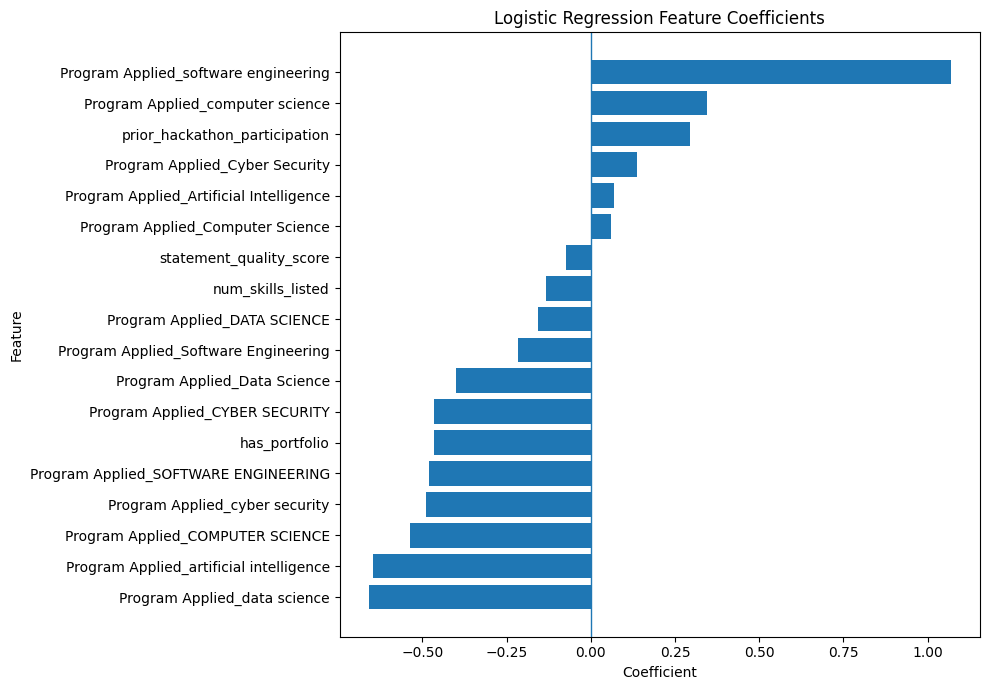

In [19]:
plt.figure(figsize=(10, 7))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.axvline(0, linewidth=1)
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Feature Coefficients")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
### Feature Coefficients Interpretation

The Logistic Regression coefficients show how each feature is associated with the model's prediction of internship selection.

Positive coefficients indicate a positive association with selection, while negative coefficients indicate a negative association.

These results should be interpreted cautiously because the dataset is relatively small and several features were simulated for this exercise. The coefficients show what the model learned from this dataset; they do not prove that any feature causes internship selection.

In [ ]:
## Model Limitations

There are several important limitations to this model:

1. The dataset is relatively small, with only 160 applicants having confirmed outcomes.
2. Four of the model features were simulated rather than collected from real applicant records.
3. The simulated features may not accurately represent real applicant behavior or selection criteria.
4. The dataset contains inconsistent capitalization in program names, which can create separate encoded categories.
5. The model uses a limited number of applicant characteristics and does not include potentially important real-world factors.
6. The test set is small, so the reported performance metrics may vary with different samples.
7. The model shows associations in this dataset; it does not prove that any feature causes an applicant to be selected.

In [ ]:
# Executive Summary

This project explored whether applicant information could be used to estimate internship selection outcomes.

The analysis used information about applicants' skills, portfolio availability, previous hackathon participation, statement quality, and applied program. Some of these additional characteristics were simulated because they were not available in the original dataset.

A Logistic Regression model was trained using confirmed applicant outcomes. The model achieved an accuracy of 50.00%, with a precision of 58.33% and a recall of 38.89% on the test data.

These results suggest that the current model is not reliable enough to be used as an automated selection system. The model should therefore be treated as an exploratory analysis rather than a decision-making tool.

For future improvement, the organization should collect real historical information about applicant skills, portfolios, assessments, interview performance, and other relevant factors. A larger dataset with consistently recorded outcomes would also allow more reliable model evaluation.

The main recommendation is to use machine learning only as a supporting analytical tool, while keeping final internship selection decisions under human review.

In [20]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall"],
    "Score": [accuracy, precision, recall]
})

results["Score"] = results["Score"].round(4)

results

,Metric,Score
0,Accuracy,0.5000
1,Precision,0.5833
2,Recall,0.3889
